In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys
sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

import gaussoptfuncs

In [2]:
from skimage.filters import gaussian, median

In [171]:
#data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = '../Camera_Calibrations/Ximea_Camera/'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
print(np.median(gain))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
print(np.median(offset))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
print(np.median(variance))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
print(np.median(readnoise))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))


0.414377152294
32.3464
0.9374151
2.33716799668


In [368]:
R, G, B, wavelength = S_F.getpixelefficiency()

#B[wavelength < 500] = 0.95
#B[wavelength >= 500] = 0
#G[(wavelength < 500) | (wavelength > 600)] = 0
#G[(wavelength < 600) & (wavelength >= 500)] = 0.95
#R[wavelength < 600] = 0
#R[wavelength >= 600] = 0.95

pixel_QYs = np.vstack([B, G, R])
image_size = 12
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), 0.5)
camera_parameters["offset"] = np.full((image_size, image_size), 0)
camera_parameters["variance"] = np.full((image_size, image_size), 0.1)
camera_parameters["readnoise"] = np.full((image_size, image_size), 0.1)
camera_parameters["rqe"] = np.full((image_size, image_size), 1)
camera_parameters["pixel_QYs"] = np.vstack([B, G, R])
camera_parameters["pixel_order"] = ['B', 'G', 'R']
camera_parameters["pixel_order_indices"] = [0, 1, 2]

camera_parameters["masks"] = M_F.get_masks(size_x=image_size, size_y=image_size)
#camera_parameters["masks"] = masks

In [369]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
shortpass_filter = 'semrock-bsp01-785r'
longpass_filter = 'semrock-blp01-635r'
longpass_green_filter = 'semrock-blp02-561r'
bandpass_green_filter = 'semrock-ff01-582-64'
longpass_blue_filter = 'semrock-blp01-488r'
bandpass_blue_filter = 'semrock-ff01-520-44'
filters = [dichroic_mirror, longpass_green_filter]
dyes = ['ATTO 550']
_, dye_library = S_F.get_pixel_fractions_dye_and_filters(
                    dyes,
                    filters,
                    wavelength,
                    camera_parameters["pixel_QYs"],
                )


In [370]:
import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [371]:
pixel_size = 69
image_size = pixel_size * np.array(camera_parameters["gain"].shape)

In [372]:
positions = np.array([0.5, 0.5])*image_size-(69/2)
X0, Y0 = np.meshgrid(positions, positions[::-1])
X0 = X0.ravel()
Y0 = Y0.ravel()

In [373]:

x0y0 = {}
n_photons = {}
n_ph = 4000
for i, dye in enumerate(dyes):
    background_photons = int(40)
    
    NA = 1.49
    s = 1
    n_photons[dye] = np.full(s, n_ph)
    x0y0[dye] = np.zeros([s, 2, 1])
    x0y0[dye][:, :, :] = np.array([[X0[i], Y0[i]]]).T
    
    
average_emission_wavelengths, dye_pixel_efficiency = S_F.get_pixel_fractions_dye_and_filters(dyes, filters, wavelength, pixel_QYs)        
    
    
bayer_image_example, smoothed_image, normal_image =  MSF.gen_camera_image_stack(camera_parameters, wavelength,
                        average_emission_wavelengths, dye_pixel_efficiency, 
                        n_photons, x0y0, smoothing_function=smoothing_function, background_photons=background_photons, NA=NA, pixel_size=pixel_size, 
                        return_normal_image=True,)
        


In [367]:
photoelectrons_bayer_sharp = np.divide(
                np.divide(
                    np.subtract(bayer_image_example, camera_parameters["offset"]),
                    camera_parameters["gain"],
                ),
                camera_parameters["rqe"],
            )

In [374]:
photoelectrons_bayer = np.divide(
                np.divide(
                    np.subtract(bayer_image_example, camera_parameters["offset"]),
                    camera_parameters["gain"],
                ),
                camera_parameters["rqe"],
            )

In [333]:
photoelectrons_normal = np.divide(
                np.divide(
                    np.subtract(normal_image, camera_parameters["offset"]),
                    camera_parameters["gain"],
                ),
                camera_parameters["rqe"],
            )

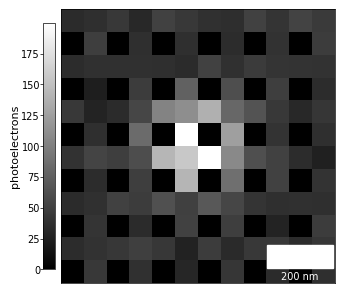

In [459]:
fig, axs = plotter.one_column_plot()

data = photoelectrons_bayer_sharp
axs = plotter.image_plot(axs, data, scalebarlabel='200 nm', scalebarsize=200, vmin=np.percentile(data, 0.01), vmax=np.percentile(data, 99))
#axs.set_xlim([3, 13])
#axs.set_ylim([3, 13])

plt.savefig('ATTO565_exemplar_sharp.svg', dpi=600, format='svg')

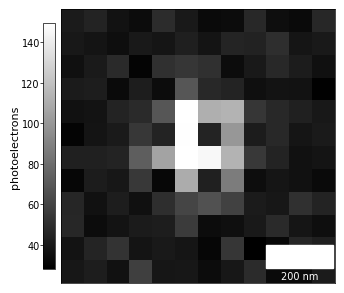

In [460]:
fig, axs = plotter.one_column_plot()

data = photoelectrons_bayer
axs = plotter.image_plot(axs, data, scalebarlabel='200 nm', scalebarsize=200, 
                         vmin=np.percentile(data, 0.01), vmax=np.percentile(data, 99))
#axs.set_xlim([3, 13])
#axs.set_ylim([3, 13])

plt.savefig('ATTO565_exemplar.svg', dpi=600, format='svg')

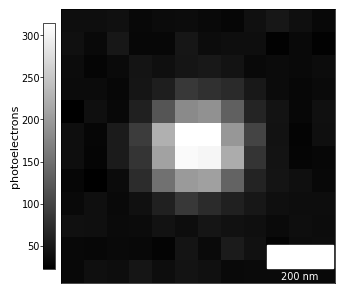

In [461]:
fig, axs = plotter.one_column_plot()

data = photoelectrons_normal
axs = plotter.image_plot(axs, data, scalebarlabel='200 nm', scalebarsize=200, vmin=np.percentile(data, 0.01), vmax=np.percentile(data, 99))
#axs.set_xlim([3, 13])
#axs.set_ylim([3, 13])

plt.savefig('ATTO565_exemplar_normal.svg', dpi=600, format='svg')

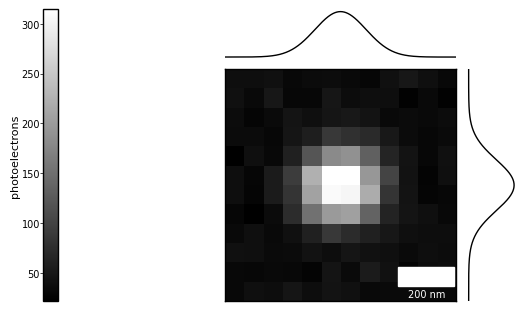

In [464]:
fig, axs = plotter.two_column_plot()

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection

data = photoelectrons_normal
axs = plotter.image_plot(axs, data, scalebarlabel='200 nm', scalebarsize=200, vmin=np.percentile(data, 0.01), vmax=np.percentile(data, 99))


# create new Axes on the right and on the top of the current Axes
divider = make_axes_locatable(axs)
# below height and pad are in inches
ax_fitx = divider.append_axes("top", 0.5, pad=0.1)
ax_fity = divider.append_axes("right", 0.5, pad=0.1)


x, y = np.mgrid[-7.0:7.0:1000j, -7.0:7.0:1000j]

# Need an (N, 2) array of (x, y) pairs.
xy = np.column_stack([x.flat, y.flat])

mu = np.array([0.0, 0.0])
sigma = PSF.sigma_PSF(NA=1.49, wavelength=average_emission_wavelengths/1000)/0.069
sigma_arr = np.array([sigma, sigma])
covariance = np.diag(sigma_arr**2)

z = multivariate_normal.pdf(xy, mean=mu, cov=covariance)

# Reshape back to a (30, 30) grid.
z = z.reshape(x.shape)
z = z/np.max(z)


def colored_line_between_pts(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified between (x, y) points by a third value.

    It does this by creating a collection of line segments between each pair of
    neighboring points. The color of each segment is determined by the
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should have a size one less than that of x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    # Create a set of line segments so that we can color them individually
    # This creates the points as an N x 1 x 2 array so that we can stack points
    # together easily to get the segments. The segments array for line collection
    # needs to be (numlines) x (points per line) x 2 (for x and y)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, **lc_kwargs)

    # Set the values used for colormapping
    lc.set_array(c)

    return ax.add_collection(lc)

ax_fity.plot(z[:, 500], x[:, 500], lw=1, color='k')
ax_fitx.plot(x[:, 500], z[:, 500], lw=1, color='k')

ax_fity.set_ylim([np.min(x)+1, np.max(x)-1])
ax_fitx.set_xlim([np.min(x)+1, np.max(x)-1])
ax_fitx.set_ylim([np.min(z)-0.05, np.max(z)*1.05])
ax_fity.set_xlim([np.min(z)-0.05, np.max(z)*1.05])

ax_fitx.axis("off")
ax_fity.axis("off")

plt.savefig('ATTO565_exemplar_normal_fit.svg', dpi=600, format='svg')

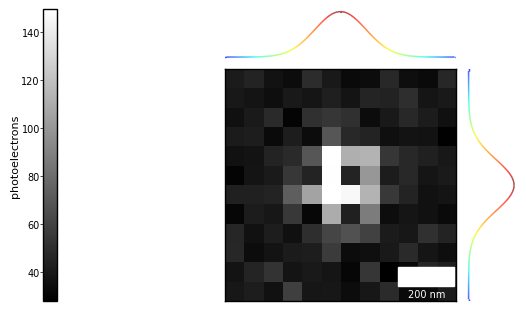

In [463]:
fig, axs = plotter.two_column_plot()

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection

data = photoelectrons_bayer
axs = plotter.image_plot(axs, data, scalebarlabel='200 nm', scalebarsize=200, vmin=np.percentile(data, 0.01), vmax=np.percentile(data, 99))


# create new Axes on the right and on the top of the current Axes
divider = make_axes_locatable(axs)
# below height and pad are in inches
ax_fitx = divider.append_axes("top", 0.5, pad=0.1)
ax_fity = divider.append_axes("right", 0.5, pad=0.1)


x, y = np.mgrid[-7.0:7.0:1000j, -7.0:7.0:1000j]

# Need an (N, 2) array of (x, y) pairs.
xy = np.column_stack([x.flat, y.flat])

mu = np.array([0.0, 0.0])
sigma = PSF.sigma_PSF(NA=1.49, wavelength=average_emission_wavelengths/1000)/0.069
sigma_arr = np.array([sigma, sigma])
covariance = np.diag(sigma_arr**2)

z = multivariate_normal.pdf(xy, mean=mu, cov=covariance)

# Reshape back to a (30, 30) grid.
z = z.reshape(x.shape)
z = z/np.max(z)


def colored_line_between_pts(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified between (x, y) points by a third value.

    It does this by creating a collection of line segments between each pair of
    neighboring points. The color of each segment is determined by the
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should have a size one less than that of x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    # Create a set of line segments so that we can color them individually
    # This creates the points as an N x 1 x 2 array so that we can stack points
    # together easily to get the segments. The segments array for line collection
    # needs to be (numlines) x (points per line) x 2 (for x and y)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, **lc_kwargs)

    # Set the values used for colormapping
    lc.set_array(c)

    return ax.add_collection(lc)

c = np.hstack([np.linspace(0, 1, int(len(x[:, 500])/2)), np.linspace(1, 0, int(len(x[:, 500])/2))])
colored_line_between_pts(x[:, 500], z[500, :], c, ax_fitx, linewidth=1, cmap="jet")

colored_line_between_pts(z[500, :], x[:, 500], c, ax_fity, linewidth=1, cmap="jet")

ax_fity.set_ylim([np.min(x)+1, np.max(x)-1])
ax_fitx.set_xlim([np.min(x)+1, np.max(x)-1])
ax_fitx.set_ylim([np.min(z)-0.05, np.max(z)*1.05])
ax_fity.set_xlim([np.min(z)-0.05, np.max(z)*1.05])

ax_fitx.axis("off")
ax_fity.axis("off")

#axs[0].set_xlim([3, 13])
#axs[0].set_ylim([3, 13])

plt.savefig('ATTO565_exemplar_bayer_fit.svg', dpi=600, format='svg')

In [442]:
len(x[:, 500])/2

500.0

In [433]:
np.max(x)

6.0

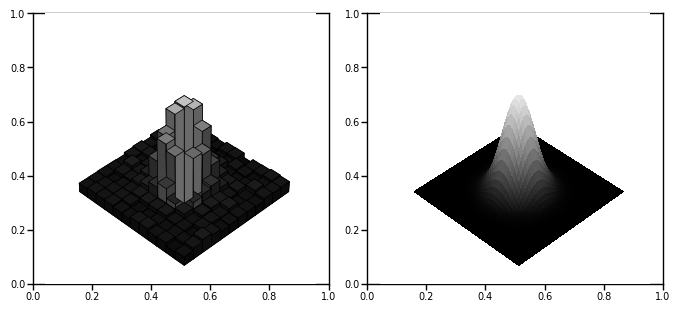

In [335]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

ax[0] = fig.add_subplot(121, projection='3d')

xpos, ypos = np.meshgrid(range(photoelectrons_normal.shape[1]), range(photoelectrons_normal.shape[0]))
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)

# Bar dimensions (1x1 pixel bars)
dx = dy = np.ones_like(xpos)
dz = photoelectrons_normal.ravel()

# Create 3D bar plot
ax[0].bar3d(xpos, ypos, zpos, dx, dy, dz, 
         color=cm.gist_gray(dz/dz.max()),
         edgecolor='black',      # Color of the lines between bars
         linewidth=0.5)

ax[0].set_axis_off()
ax[0].view_init(elev=40, azim=45, roll=0)
from scipy.stats import multivariate_normal

x, y = np.mgrid[-6.0:6.0:1000j, -6.0:6.0:1000j]

# Need an (N, 2) array of (x, y) pairs.
xy = np.column_stack([x.flat, y.flat])

mu = np.array([0.0, 0.0])
sigma = PSF.sigma_PSF(NA=1.49, wavelength=average_emission_wavelengths/1000)/0.069
sigma_arr = np.array([sigma, sigma])
covariance = np.diag(sigma_arr**2)

z = multivariate_normal.pdf(xy, mean=mu, cov=covariance)

# Reshape back to a (30, 30) grid.
z = z.reshape(x.shape)
z = z/np.max(z)
z = z * np.max(Z)





ax[1] = fig.add_subplot(122, projection='3d')
ax[1].view_init(elev=40, azim=45, roll=0)

ax[1].plot_surface(x,y,z, cmap=cm.gist_gray,
                       linewidth=0, vmax=np.max(z)*1.1, antialiased=False)
ax[1].set_axis_off()



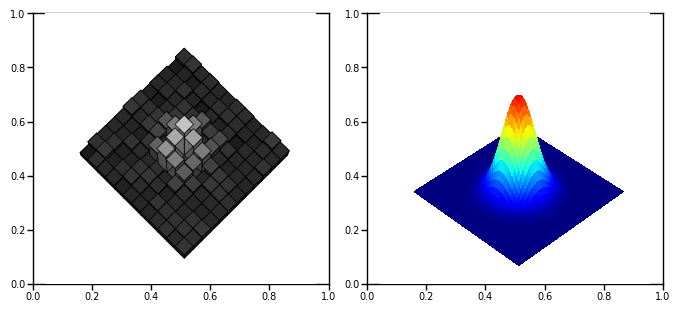

In [344]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig, ax = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

ax[0] = fig.add_subplot(121, projection='3d')

xpos, ypos = np.meshgrid(range(photoelectrons_normal.shape[1]), range(photoelectrons_normal.shape[0]))
xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)

# Bar dimensions (1x1 pixel bars)
dx = dy = np.ones_like(xpos)
dz = photoelectrons_bayer.ravel()

# Create 3D bar plot
ax[0].bar3d(xpos, ypos, zpos, dx, dy, dz, 
         color=cm.gist_gray(dz/dz.max()),
         edgecolor='black',      # Color of the lines between bars
         linewidth=0.5)

ax[0].set_axis_off()
ax[0].view_init(elev=80, azim=45, roll=0)
from scipy.stats import multivariate_normal






ax[1] = fig.add_subplot(122, projection='3d')
ax[1].view_init(elev=40, azim=45, roll=0)

ax[1].plot_surface(x,y,z, cmap=cm.jet,
                       linewidth=0, vmax=np.max(z)*1.1, antialiased=False)
ax[1].set_axis_off()